## Imports

In [1]:
import numpy as np
import pandas as pd

import sklearn as sk
from sklearn import base
from sklearn import calibration
from sklearn import cluster
from sklearn import compose
from sklearn import covariance
from sklearn import cross_decomposition
from sklearn import datasets
from sklearn import decomposition
from sklearn import discriminant_analysis
from sklearn import dummy
from sklearn import ensemble
from sklearn import exceptions
from sklearn import experimental
from sklearn import feature_extraction
from sklearn import feature_selection
from sklearn import gaussian_process
from sklearn import impute
from sklearn import inspection
from sklearn import isotonic
from sklearn import kernel_approximation
from sklearn import kernel_ridge
from sklearn import linear_model
from sklearn import manifold
from sklearn import metrics
from sklearn import mixture
from sklearn import model_selection
from sklearn import multiclass
from sklearn import multioutput
from sklearn import naive_bayes
from sklearn import neighbors
from sklearn import neural_network
from sklearn import pipeline
from sklearn import preprocessing
from sklearn import random_projection
from sklearn import semi_supervised
from sklearn import svm
from sklearn import tree
from sklearn import utils

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Analisi

## Es. 0

In [2]:
df = pd.read_csv('dataset.csv', sep=',')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## Es.1
Quante sono le istanze contenute nel dataset? _____ Il dataset è completo (cioè per 
ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati – non 
esistono “missing values”)? _____  Il dataset è bilanciato per quanto riguarda la classe da 
predire? ______ (punti 1)

In [3]:
print('Rows (instances):', df.shape[0])

Rows (instances): 7043


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Not balanced, much more non-churn than churn.

## Es. 2
Verificare se i clienti con contratto a lungo termine (Contract="Two year") hanno in 
media  una  spesa  mensile  (MonthlyCharges)  inferiore  rispetto  a  quelli con contratti 
mensili o annuali. (punti 2)

In [6]:
longterm = df[df['Contract'] == 'Two year']
others = df[df['Contract'] != 'Two year']

lt_mean = longterm['MonthlyCharges'].mean()
o_mean = others['MonthlyCharges'].mean()

print(lt_mean)
print(o_mean)
print(lt_mean < o_mean)

60.77041297935103
66.02669222139117
True


## Es. 3
Discretizzare tenure (anzianità del cliente) in 3 gruppi (bassa, media, alta). Creare 
una  tabella  pivot  che  mostri  la  percentuale  di  abbandono  (Churn)  per  gruppo  di 
anzianità e tipo di contratto. I clienti con anzianità bassa e contratto mensile hanno una 
probabilità maggiore di abbandonare? (punti 3) 

In [7]:
tenure_discr = pd.cut(df['tenure'], 3, labels=['bassa', 'media', 'alta'])
tenure_discr

0       bassa
1       media
2       bassa
3       media
4       bassa
        ...  
7038    bassa
7039     alta
7040    bassa
7041    bassa
7042     alta
Name: tenure, Length: 7043, dtype: category
Categories (3, object): ['bassa' < 'media' < 'alta']

In [8]:
df['tenure'] = tenure_discr
df['tenure']

0       bassa
1       media
2       bassa
3       media
4       bassa
        ...  
7038    bassa
7039     alta
7040    bassa
7041    bassa
7042     alta
Name: tenure, Length: 7043, dtype: category
Categories (3, object): ['bassa' < 'media' < 'alta']

In [9]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}) # Churn now a boolean column

In [10]:
pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc=['sum', 'count']) # two agg functions at the same time
pt

/var/folders/ph/t7gwl3k17_l0cxktc3ll17600000gn/T/ipykernel_62177/2909912098.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc=['sum', 'count']) # two agg functions at the same time
/var/folders/ph/t7gwl3k17_l0cxktc3ll17600000gn/T/ipykernel_62177/2909912098.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc=['sum', 'count']) # two agg functions at the same time


sum count
                      Churn Churn
tenure Contract                  
bassa  Month-to-month  1302  2731
       One year          29   321
       Two year           0   158
media  Month-to-month   264   802
       One year          55   518
       Two year           6   274
alta   Month-to-month    89   342
       One year          82   634
       Two year          42  1263

In [11]:
pt['churn_rate_per_category'] = pt['sum']/pt['count']
pt

sum count churn_rate_per_category
                      Churn Churn                        
tenure Contract                                          
bassa  Month-to-month  1302  2731                0.476748
       One year          29   321                0.090343
       Two year           0   158                0.000000
media  Month-to-month   264   802                0.329177
       One year          55   518                0.106178
       Two year           6   274                0.021898
alta   Month-to-month    89   342                0.260234
       One year          82   634                0.129338
       Two year          42  1263                0.033254

In [12]:
# Shorter solution - note that the mean applied to a boolean sequence computes directly the probability of the positive, of 1.
pt_direct = pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc='mean')
pt_direct

/var/folders/ph/t7gwl3k17_l0cxktc3ll17600000gn/T/ipykernel_62177/605085413.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt_direct = pt = df.pivot_table(index=['tenure', 'Contract'], values='Churn', aggfunc='mean')


Churn
tenure Contract                
bassa  Month-to-month  0.476748
       One year        0.090343
       Two year        0.000000
media  Month-to-month  0.329177
       One year        0.106178
       Two year        0.021898
alta   Month-to-month  0.260234
       One year        0.129338
       Two year        0.033254

In [13]:
pt_direct.style.format("{:.2%}")

I clienti con ('bassa', 'month-to-month') hanno la probabilità più alta di churn.

## Es. 4
Determinare  se  l’adozione  di  almeno  un  servizio  extra  (OnlineSecurity, 
OnlineBackup,  DeviceProtection,  TechSupport,  StreamingTV, 
StreamingMovies)  riduce  il tasso di abbandono. (punti 2) Creare una nuova feature 
che conta il numero di servizi aggiuntivi attivi per cliente e verificare con un grafico se il 
tasso di abbandono diminuisce all’aumentare del numero di servizi attivi. (punti 2)

In [14]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [15]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
mapping = {'Yes': 1, 'No': 0, 'No internet service' : 0}

for col in services:
    df[col] = df[col].map(mapping)
    print(df[col].isnull().sum())

df

0
0
0
0
0
0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,bassa,No,No phone service,DSL,0,...,0,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,media,Yes,No,DSL,1,...,1,0,0,0,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,bassa,Yes,No,DSL,1,...,0,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,media,No,No phone service,DSL,1,...,1,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,bassa,Yes,No,Fiber optic,0,...,0,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,bassa,Yes,Yes,DSL,1,...,1,1,1,1,One year,Yes,Mailed check,84.80,1990.5,0
7039,2234-XADUH,Female,0,Yes,Yes,alta,Yes,Yes,Fiber optic,0,...,1,0,1,1,One year,Yes,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,Female,0,Yes,Yes,bassa,No,No phone service,DSL,1,...,0,0,0,0,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,bassa,Yes,Yes,Fiber optic,0,...,0,0,0,0,Month-to-month,Yes,Mailed check,74.40,306.6,1


In [16]:
df[(df['OnlineSecurity']==1) | (df['OnlineBackup']==1) |
 (df['DeviceProtection']==1) | (df['TechSupport']==1) | (df['StreamingTV']==1) | (df['StreamingMovies']==1)]['Churn'].mean()

np.float64(0.28897180762852404)

In [17]:
df[(df['OnlineSecurity']==0) & (df['OnlineBackup']==0) &
 (df['DeviceProtection']==0) & (df['TechSupport']==0) & (df['StreamingTV']==0) & (df['StreamingMovies']==0)]['Churn'].mean()

np.float64(0.21406038756196485)

Risposta alla prima parte dell'esercizio: no, in media non diminuisce il churn avendo almeno un servizio.

In [18]:
df['ActiveServices'] = df[services].sum(axis=1)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ActiveServices
0,7590-VHVEG,Female,0,Yes,No,bassa,No,No phone service,DSL,0,...,0,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,0,1
1,5575-GNVDE,Male,0,No,No,media,Yes,No,DSL,1,...,0,0,0,One year,No,Mailed check,56.95,1889.5,0,2
2,3668-QPYBK,Male,0,No,No,bassa,Yes,No,DSL,1,...,0,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,1,2
3,7795-CFOCW,Male,0,No,No,media,No,No phone service,DSL,1,...,1,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,0,3
4,9237-HQITU,Female,0,No,No,bassa,Yes,No,Fiber optic,0,...,0,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,bassa,Yes,Yes,DSL,1,...,1,1,1,One year,Yes,Mailed check,84.80,1990.5,0,5
7039,2234-XADUH,Female,0,Yes,Yes,alta,Yes,Yes,Fiber optic,0,...,0,1,1,One year,Yes,Credit card (automatic),103.20,7362.9,0,4
7040,4801-JZAZL,Female,0,Yes,Yes,bassa,No,No phone service,DSL,1,...,0,0,0,Month-to-month,Yes,Electronic check,29.60,346.45,0,1
7041,8361-LTMKD,Male,1,Yes,No,bassa,Yes,Yes,Fiber optic,0,...,0,0,0,Month-to-month,Yes,Mailed check,74.40,306.6,1,0


In [19]:
churn_rate = df['Churn'].groupby(df['ActiveServices']).mean()
churn_rate

ActiveServices
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64

<Axes: xlabel='Active Services', ylabel='Churn'>

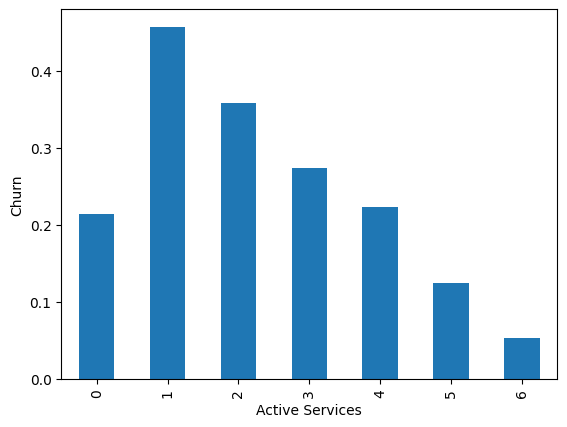

In [20]:
churn_rate.plot(kind='bar', xlabel='Active Services', ylabel='Churn')

Se si hanno dei servizi attivi, all'aumentare dei servizi diminuisce il tasso di abbandono.

# Trasformazione e predizione

## Es. 1
Si vuole predire l’abbandono dei clienti (Churn). Ricaricare il dataset originale, 
eliminare eventuali attributi inutili (giustificare la scelta) e istanze che contengono 
valori nulli, trasformare opportunamente valori categorici e dividere il dataset in 75% 
train e 25% test, preservando le proporzioni delle classi nella colonna target. 
Confrontare la predizione ottenuta sia sul dataset train sia sul dataset test dai 
classificatori LogisticRegression, RandomForestClassifier e da un dummy classifier a 
scelta. Effettuare alcune considerazioni sui risultati ottenuti, tenendo in considerazione 
i valori di accuracy, F1 e della confusion matrix. (punti 4) 

In [21]:
df = pd.read_csv('dataset.csv', sep=',')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [22]:
# Removed id to prevent overfitting
df = df.drop('customerID', axis=1)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [23]:
df = df.dropna()
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [24]:
categorical_cols = [col for col in df.columns if df[col].dtype == object]
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [25]:
enc = preprocessing.OrdinalEncoder()
df[categorical_cols] = enc.fit_transform(df[categorical_cols])
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,29.85,2505.0,0.0
1,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0,56.95,1466.0,0.0
2,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,53.85,157.0,1.0
3,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,42.30,1400.0,0.0
4,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,70.70,925.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0,1.0,1.0,24,1.0,2.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,84.80,1597.0,0.0
7039,0.0,0,1.0,1.0,72,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,1.0,103.20,5698.0,0.0
7040,0.0,0,1.0,1.0,11,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,29.60,2994.0,0.0
7041,1.0,1,1.0,0.0,4,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,74.40,2660.0,1.0


In [26]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [27]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

In [28]:
logreg = linear_model.LogisticRegression()
rfc = ensemble.RandomForestClassifier()
dummyclf = dummy.DummyClassifier(strategy='stratified')
models = [logreg, rfc, dummyclf]

for model in models:
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print(y_train_pred)
    print(y_test_pred, '\n')
    print("Accuracy train: {:0.2f}".format(metrics.accuracy_score(y_train, y_train_pred)))
    print("Accuracy test: {:0.2f}".format(metrics.accuracy_score(y_test, y_test_pred)))
    print("F1 Score train: {:0.2f}".format(metrics.f1_score(y_train, y_train_pred)))
    print("F1 Score test: {:0.2f}".format(metrics.f1_score(y_test, y_test_pred)))
    print('Confusion matrix train\n', metrics.confusion_matrix(y_train, y_train_pred))
    print('Confusion matrix test\n', metrics.confusion_matrix(y_test, y_test_pred))
    print('\n\n')

/opt/anaconda3/envs/BDTA/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[0. 0. 1. ... 0. 1. 0.]
[1. 0. 0. ... 1. 0. 0.] 

Accuracy train: 0.80
Accuracy test: 0.78
F1 Score train: 0.61
F1 Score test: 0.56
Confusion matrix train
 [[3434  446]
 [ 600  802]]
Confusion matrix test
 [[1124  170]
 [ 219  248]]



[0. 0. 0. ... 0. 0. 0.]
[0. 0. 0. ... 1. 0. 1.] 

Accuracy train: 1.00
Accuracy test: 0.79
F1 Score train: 1.00
F1 Score test: 0.54
Confusion matrix train
 [[3874    6]
 [   8 1394]]
Confusion matrix test
 [[1166  128]
 [ 248  219]]



[0. 0. 0. ... 1. 0. 0.]
[1. 0. 0. ... 0. 0. 0.] 

Accuracy train: 0.61
Accuracy test: 0.60
F1 Score train: 0.27
F1 Score test: 0.27
Confusion matrix train
 [[2865 1015]
 [1024  378]]
Confusion matrix test
 [[931 363]
 [338 129]]





## Es. 2
La predizione di RandomForestClassifier è influenzata dal genere? Valutare sui dati di 
test se la probabilità di abbandono calcolata sulle donne è la stessa per gli uomini (punti 
2). Valutare se l’accuratezza di predizione ottenuta negli uomini è la stessa ottenuta 
nelle donne (punti 2). Eliminare l’attributo gender e valutare se l’accuratezza ottenuta 
negli uomini è la stessa ottenuta nelle donne (punti 1).

In [29]:
enc.categories_

[array(['Female', 'Male'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'No phone service', 'Yes'], dtype=object),
 array(['DSL', 'Fiber optic', 'No'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['Month-to-month', 'One year', 'Two year'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array(['Bank transfer (automatic)', 'Credit card (automatic)',
        'Electronic check', 'Mailed check'], dtype=object),
 array([' ', '100.2', '100.25', ..., '999.45', '999.8', '999.9'],
       dtype=object),
 array(['No', 'Yes'], dtype=object)]

In [30]:
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

In [31]:
X_test['pred'] = y_pred

In [32]:
men = X_test[X_test['gender'] == 1]
women = X_test[X_test['gender'] == 0]
prob_man = men[men['pred']==1].shape[0] / men.shape[0]
prob_woman = women[women['pred']==1].shape[0] / women.shape[0]

print('Probabilità che un uomo abbandoni: {}'.format(prob_man))
print('Probabilità che una donna abbandoni: {}'.format(prob_woman))

Probabilità che un uomo abbandoni: 0.18092105263157895
Probabilità che una donna abbandoni: 0.20848056537102475


In [33]:
X_test['real'] = y_test.values

In [34]:
acc_men = metrics.accuracy_score(X_test[X_test['gender']==1]['real'], men['pred'])
acc_women = metrics.accuracy_score(X_test[X_test['gender']==0]['real'], women['pred'])
print('Accuracy sugli uomini:', acc_men)
print('Accuracy sulle donne:', acc_women)

Accuracy sugli uomini: 0.7817982456140351
Accuracy sulle donne: 0.7997644287396938


In [35]:
X_test = X_test.drop(['real', 'pred'], axis=1)
X_test

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
541,0.0,0,0.0,0.0,11,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,3.0,58.95,4922.0
1128,1.0,0,0.0,0.0,27,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,2.0,19.40,4422.0
6374,0.0,0,1.0,1.0,72,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,3.0,20.70,879.0
5685,1.0,0,1.0,1.0,45,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,2.0,19.20,6334.0
2144,1.0,0,0.0,0.0,3,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,3.0,50.50,867.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,1.0,0,1.0,1.0,40,1.0,0.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,3.0,19.60,6050.0
3338,0.0,0,0.0,0.0,12,1.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,1.0,2.0,89.40,190.0
2582,0.0,0,0.0,1.0,12,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,0.0,1.0,2.0,105.30,506.0
701,1.0,0,0.0,0.0,35,1.0,2.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,83.15,2462.0


In [36]:
index_men = X_test[X_test['gender']==1].index
index_women = X_test[X_test['gender']==0].index
index_men

Index([1128, 5685, 2144,  680, 1327, 2041, 6357, 2904,  717, 6097,
       ...
       1437, 5812, 1392, 2363, 3095, 5478, 5339, 2164,  981,  701],
      dtype='int64', length=912)

In [37]:
X_train = X_train.drop('gender', axis=1)
X_test = X_test.drop('gender', axis=1)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

X_test['real'] = y_test
X_test['pred'] = y_pred

acc_men = metrics.accuracy_score(X_test.loc[index_men]['real'], X_test.loc[index_men]['pred'])
acc_women = metrics.accuracy_score(X_test.loc[index_women]['real'], X_test.loc[index_women]['pred'])

print('Accuracy sugli uomini:', acc_men)
print('Accuracy sulle donne:', acc_women)

Accuracy sugli uomini: 0.7807017543859649
Accuracy sulle donne: 0.7926972909305064


## Es.3
A partire dal dataset utilizzato al punto 1, trovare i migliori parametri di max_depth 
e n_estimators in RandomForestClassifier. Come cambia l'F1-score? (punti 2)

In [38]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

In [39]:
parameters = {'max_depth': [5, 10, 20, None], 'n_estimators': [50, 100, 200, 300]}
rfc = ensemble.RandomForestClassifier()

gridsearch = model_selection.GridSearchCV(estimator=rfc, param_grid=parameters, scoring='f1')
gridsearch.fit(X_train, y_train)
print('CV results\n', gridsearch.cv_results_)
print('Best params:', gridsearch.best_params_)
print('Best estimator:', gridsearch.best_estimator_)
print('Best score (F1):', gridsearch.best_score_)

CV results
 {'mean_fit_time': array([0.06042509, 0.11864882, 0.23582315, 0.35051408, 0.0886827 ,
       0.1759882 , 0.35072732, 0.52431078, 0.10339808, 0.20701871,
       0.41422539, 0.61755319, 0.10433946, 0.20857019, 0.41590433,
       0.62240925]), 'std_fit_time': array([0.00144613, 0.00147783, 0.00295358, 0.00193546, 0.00113604,
       0.00095768, 0.00224768, 0.00336669, 0.00087313, 0.00051763,
       0.00386735, 0.00213933, 0.00077819, 0.00288018, 0.00336174,
       0.00273019]), 'mean_score_time': array([0.00326233, 0.00526733, 0.00942478, 0.01363797, 0.00454917,
       0.00802236, 0.01485248, 0.022616  , 0.00529203, 0.00954456,
       0.0179544 , 0.02627563, 0.00526814, 0.00953884, 0.01791911,
       0.02645535]), 'std_score_time': array([8.14016197e-05, 3.16238317e-05, 8.25887740e-05, 1.33236391e-04,
       1.49817014e-04, 7.11632772e-05, 1.57060012e-04, 1.74475527e-03,
       9.26581348e-05, 6.97463633e-05, 1.89135245e-04, 2.53310512e-04,
       6.17343742e-05, 1.47905125e-04,

## Es. 4
A partire dal dataset originale, dopo aver applicato un Label Encoder alle feature 
categoriche, considerare le 5 feature più correlate (positivamente o negativamente) a 
Churn e verificare se la predizione di RandomForestClassifier migliora. (punti 3)

In [40]:
df = pd.read_csv('dataset.csv', sep=',')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [41]:
categorical_cols = [col for col in df.columns if df[col].dtype == object]

enc = preprocessing.LabelEncoder()
for col in categorical_cols:
    df[col] = enc.fit_transform(df[col])

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4853,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1597,0
7039,1525,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0
7040,3367,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2994,0
7041,5934,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,2660,1


In [42]:
correlation_matrix = df.corr()
corr_Churn = correlation_matrix['Churn'].abs().sort_values(ascending=False)
top_5_corr_features = corr_Churn.iloc[1:6].index.tolist()
top_5_corr_features

['Contract', 'tenure', 'OnlineSecurity', 'TechSupport', 'OnlineBackup']

In [43]:
X = df[top_5_corr_features]
y = df['Churn']
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

rfc = ensemble.RandomForestClassifier()

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred))


Accuracy: 0.7393526405451448
F1 Score: 0.5111821086261981


## Es. 5
Creare una pipeline che, a partire dal dataset originale, discretizza MonthlyCharges in 
5 gruppi, applica OneHotEncoder alle variabili categoriche e usa StandardScaler sulle 
variabili numeriche. Applicare il RandomForestClassifier con i valori migliori dei 
parametri analizzati nel punto 3 e confrontare i risultati. (punti 3) 

In [44]:
df = pd.read_csv('dataset.csv', sep=',')
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']
enc = preprocessing.LabelEncoder()
y = enc.fit_transform(y)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, random_state=0)


['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges'] 
 ['SeniorCitizen', 'tenure']
Accuracy: 0.7484383872799546
F1 Score: 0.1157684630738523


<Axes: >

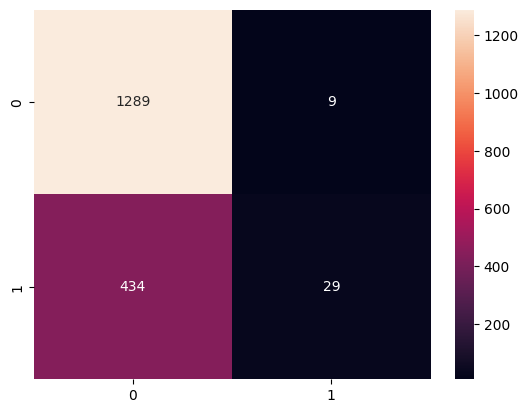

In [45]:
categorical_cols = [col for col in X_train.columns if X_train[col].dtype == object]
numerical_cols = [col for col in X_train.columns if X_train[col].dtype in ['int64', 'float64']]
numerical_cols.remove('MonthlyCharges')
print(categorical_cols, '\n', numerical_cols)

preprocessor = compose.ColumnTransformer(transformers=[
    ('discr', preprocessing.KBinsDiscretizer(n_bins=5), ['MonthlyCharges']),
    ('onehot', preprocessing.OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('stdscl', preprocessing.StandardScaler(), numerical_cols),
    
], remainder='passthrough')

model = ensemble.RandomForestClassifier(n_estimators=300, max_depth=10)

my_pipeline = pipeline.Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model),
])

my_pipeline.fit(X_train, y_train)
y_pred = my_pipeline.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("F1 Score:", metrics.f1_score(y_test, y_pred))
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cnf_matrix,annot=True,fmt="d")

Score è peggiorato.

## Es. 6
Aggiungere alla pipeline del punto 5 la funzione SelectKBest. Utilizzare la funzione di 
gridSearchCV per selezionare il K migliore e anche i valori migliori dei parametri 
max_depth e n_estimators di RandomForestClassifier (scegliere a piacere alcuni 
valori). (punti 3)

In [46]:
my_pipeline = pipeline.Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selection', feature_selection.SelectKBest()),
    ('model', model),
])

parameters = {
    'selection__k': [2, 5, 8, 10, 12],
    'model__n_estimators': [20,50,100],
    'model__max_depth': [5, 10, 20, None]
}

gridsearch = model_selection.GridSearchCV(my_pipeline, parameters, scoring='f1', n_jobs=-1)

gridsearch.fit(X_train, y_train)

print('Best params:', gridsearch.best_params_)
print('Best estimator:', gridsearch.best_estimator_)
print('Best F1 score:', gridsearch.best_score_)

Best params: {'model__max_depth': 5, 'model__n_estimators': 100, 'selection__k': 8}
Best estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('discr', KBinsDiscretizer(),
                                                  ['MonthlyCharges']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
         